In [22]:
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv('netflix_titles.csv')



In [21]:
print("FIRST 5 ROWS\n")
print(df.head())
print("")

print("LAST 5 ROWS\n")
print(df.tail())

FIRST 5 ROWS

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

In [23]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None


In [34]:
print("MISSING VALUES IN EACH COLUMN \n")
print(df.isnull().sum())
print("")

print("TOTAL NUMBER OF DUPLICATE ROWS")
print(df.duplicated().sum())

MISSING VALUES IN EACH COLUMN 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

TOTAL NUMBER OF DUPLICATE ROWS
0


In [38]:
df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])
df = df.dropna(subset=["date_added"])

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df["duration"] = df["duration"].fillna("Unknown")

In [39]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [58]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

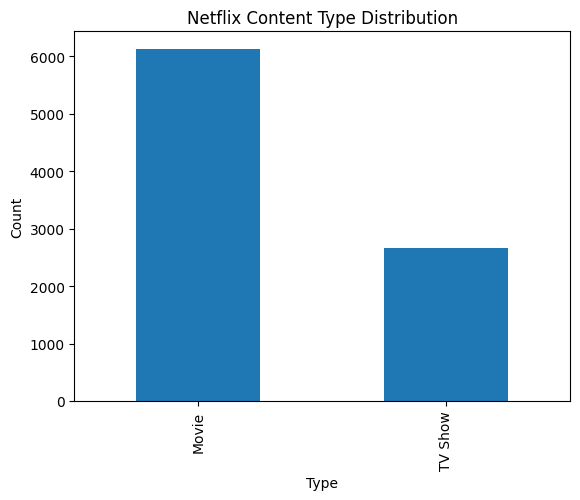

In [53]:
df["type"].value_counts().plot(kind="bar")
plt.title("Netflix Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

year_counts
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


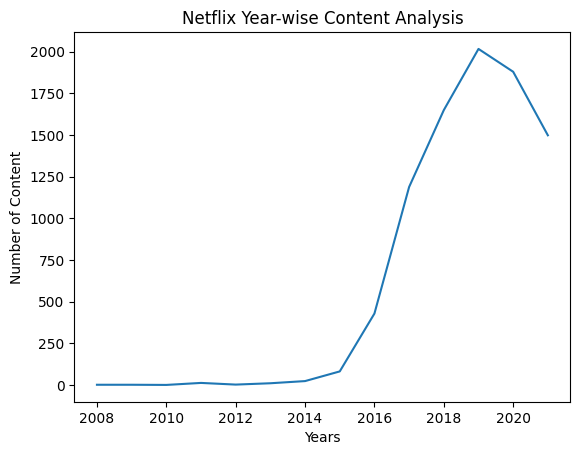

In [69]:
# df["Years"] = df["date_added"].dt.year

# print(df["Years"].value_counts())

# df["Years"].value_counts().plot()
# plt.xlabel("Years")
# plt.ylabel("Number of Content")
# plt.title("Netflix Year-wise Content Analysis")

# plt.show()

df["year_counts"] = df["date_added"].dt.year

year_sorted = df["year_counts"].value_counts().sort_index()

print(year_sorted)


year_sorted.plot()
plt.title("Netflix Year-wise Content Analysis")
plt.xlabel("Years")
plt.ylabel("Number of Content")

plt.show()

In [80]:
top = df["country"].value_counts()

top = top.drop("Unknown")

print("Top 10 Countires Producing Most Content: \n", top.head(10))

Top 10 Countires Producing Most Content: 
 country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


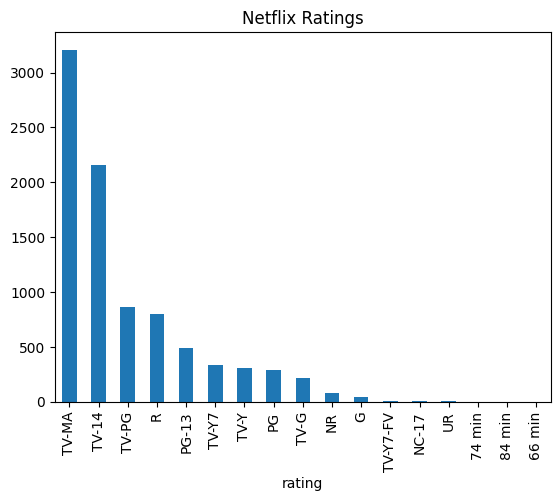

In [86]:
df["rating"].value_counts().plot(kind="bar")
plt.title("Netflix Ratings")
plt.show()


In [101]:
# df["listed_in"].value_counts()

all_genres = []

for genre in df["listed_in"] : 

    all_genres.extend(genre.split(","))

genres_series = pd.Series(all_genres)

print(genres_series.value_counts())




 International Movies        2624
Dramas                       1600
Comedies                     1210
Action & Adventure            859
Documentaries                 829
                             ... 
Romantic Movies                 3
Spanish-Language TV Shows       2
LGBTQ Movies                    1
TV Sci-Fi & Fantasy             1
Sports Movies                   1
Name: count, Length: 73, dtype: int64


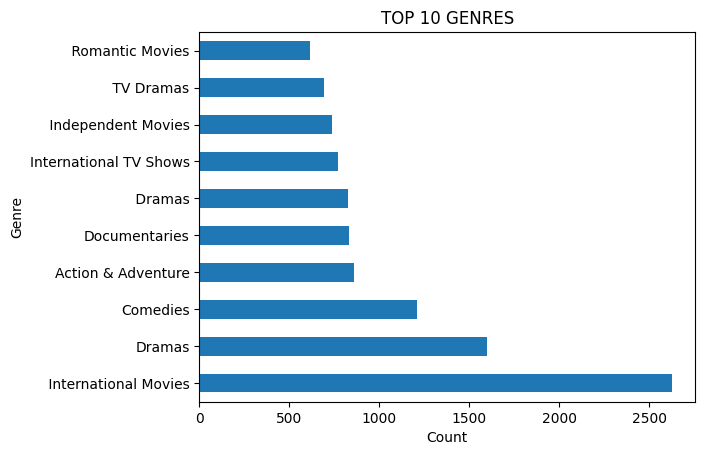

In [108]:
top_10_genres = genres_series.value_counts().head(10)

top_10_genres.plot(kind="barh")
plt.title("TOP 10 GENRES")
plt.ylabel("Genre")
plt.xlabel("Count")
plt.show()


In [120]:
OnlyMovies = df[df["type"] == "Movie"]

movie_duration = []

for duration in OnlyMovies["duration"]:
    if duration != "Unknown":
        movie_duration.append(int(duration.split(" ")[0]))

import numpy as np

print("Average Movie Duration:", round(np.mean(movie_duration), 2), "minutes")

Average Movie Duration: 99.58 minutes


(array([1.300e+01, 4.700e+01, 8.700e+01, 6.800e+01, 1.510e+02, 2.310e+02,
        3.120e+02, 5.030e+02, 1.280e+03, 1.179e+03, 8.700e+02, 5.200e+02,
        3.580e+02, 2.130e+02, 1.210e+02, 8.000e+01, 4.400e+01, 2.000e+01,
        1.100e+01, 7.000e+00, 4.000e+00, 3.000e+00, 3.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  3. ,  13.3,  23.6,  33.9,  44.2,  54.5,  64.8,  75.1,  85.4,
         95.7, 106. , 116.3, 126.6, 136.9, 147.2, 157.5, 167.8, 178.1,
        188.4, 198.7, 209. , 219.3, 229.6, 239.9, 250.2, 260.5, 270.8,
        281.1, 291.4, 301.7, 312. ]),
 <BarContainer object of 30 artists>)

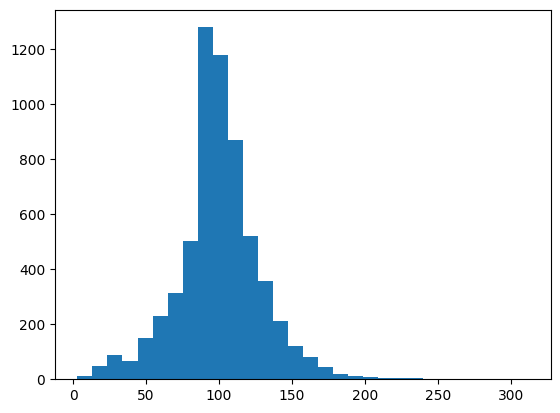

In [118]:
plt.hist(movie_duration, bins=30)

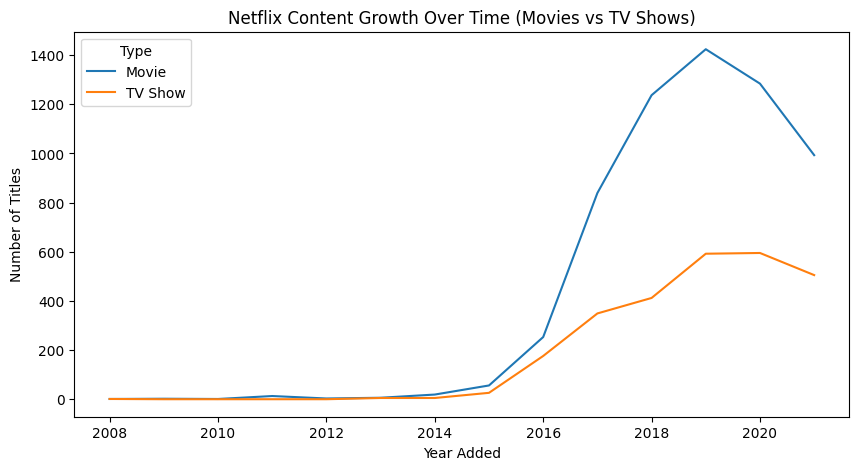

In [122]:
df["year_added"] = df["date_added"].dt.year

trend = df.groupby(["year_added", "type"]).size().unstack().fillna(0)

trend.plot(kind="line", figsize=(10,5))

plt.title("Netflix Content Growth Over Time (Movies vs TV Shows)")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

In [ ]:
## 🔥 Final Insights — Netflix EDA Project

- Netflix has significantly more Movies than TV Shows, showing its initial focus on movie-based content.

- Over time, especially after 2017, there is a clear rise in TV Shows, indicating a strategic shift toward serialized content.

- The United States is the largest contributor of content on Netflix, followed by India and the United Kingdom.

- Netflix primarily targets mature audiences, with TV-MA and TV-14 being the most common ratings.

- Drama and International Movies are the most dominant genres on the platform.

- Netflix experienced rapid content growth after 2015, showing its global expansion phase.

- Many titles include multiple genres, indicating a strong preference for hybrid and diverse content.

- Content addition trends show that Netflix is continuously expanding its library year by year, with no major decline periods.

- TV Shows show a faster growth rate in recent years compared to Movies, suggesting a long-term shift in content strategy.

- Overall, Netflix appears to be moving from a movie-heavy platform to a balanced mix of Movies and TV Shows with increasing global and diverse content.